# Динамика обучения и итоговая сводка запусков

Ноутбук собирает сохранённые `trainer_state.json` без повторного обучения. Для F1, F2, F3 и A1 строятся графики loss, learning rate и gradient norm, после чего формируется таблица с числом шагов, финальным loss и размерами LoRA-адаптеров.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_DIR = ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUNS = {
    'F1-fast': {
        'checkpoints': [ROOT / 'checkpoints' / 'f1_fast_qlora'],
        'adapter': ROOT / 'models' / 'f1_fast_qlora_adapter',
        'config': RESULTS_DIR / 'f1_fast_training_config.json',
    },
    'F2': {
        'checkpoints': [ROOT / 'checkpoints' / 'f2_qwen_r16', ROOT / 'checkpoints' / 'f2_qwen_r16_continued'],
        'adapter': ROOT / 'models' / 'f2_qwen_r16_adapter',
        'config': RESULTS_DIR / 'f2_training_config.json',
    },
    'F3-10k': {
        'checkpoints': [ROOT / 'checkpoints' / 'f3_10k_qwen_r16'],
        'adapter': ROOT / 'models' / 'f3_10k_qwen_r16_adapter',
        'config': RESULTS_DIR / 'f3_10k_training_config.json',
    },
    'A1-InternVL3': {
        'checkpoints': [ROOT / 'checkpoints' / 'a1_internvl3_2b_qlora'],
        'adapter': ROOT / 'models' / 'a1_internvl3_2b_qlora_adapter',
        'config': RESULTS_DIR / 'a1_internvl3_training_config.json',
    },
}


## 1. Чтение последнего доступного состояния каждого запуска

Trainer сохраняет накопленную историю в каждом checkpoint. Для каждой модели выбирается файл с максимальным `global_step`, поэтому одни и те же записи не дублируются.

In [2]:
log_frames = []
state_info = {}
for model_name, spec in RUNS.items():
    states = []
    for checkpoint_root in spec['checkpoints']:
        for state_path in checkpoint_root.rglob('trainer_state.json'):
            state = json.loads(state_path.read_text(encoding='utf-8'))
            states.append((state.get('global_step', 0), state_path, state))
    if not states:
        print(f'{model_name}: trainer_state.json не найден — запуск пропущен.')
        continue
    global_step, state_path, state = max(states, key=lambda item: item[0])
    history = pd.DataFrame([row for row in state.get('log_history', []) if 'loss' in row])
    history['model'] = model_name
    log_frames.append(history)
    state_info[model_name] = {'global_step': global_step, 'state_path': state_path, 'history': history}
    print(f'{model_name}: {state_path.relative_to(ROOT)}, записей loss: {len(history)}, последний шаг: {global_step}')

logs = pd.concat(log_frames, ignore_index=True)
display(logs.groupby('model').agg(first_step=('step', 'min'), last_step=('step', 'max'), log_points=('step', 'size')))

F1-fast: checkpoints\f1_fast_qlora\checkpoint-250\trainer_state.json, записей loss: 50, последний шаг: 250
F2: checkpoints\f2_qwen_r16_continued\checkpoint-200\trainer_state.json, записей loss: 40, последний шаг: 200
F3-10k: checkpoints\f3_10k_qwen_r16\checkpoint-1250\trainer_state.json, записей loss: 125, последний шаг: 1250
A1-InternVL3: checkpoints\a1_internvl3_2b_qlora\checkpoint-250\trainer_state.json, записей loss: 50, последний шаг: 250


,first_step,last_step,log_points
model,,,
A1-InternVL3,5,250,50
F1-fast,5,250,50
F2,5,200,40
F3-10k,10,1250,125


## 2. Loss по шагам

Сырые значения показываются полупрозрачными линиями, а скользящее среднее по пяти точкам помогает увидеть общий тренд. Абсолютный loss разных архитектур нельзя сравнивать напрямую из-за различий токенизаторов и внутреннего устройства моделей.

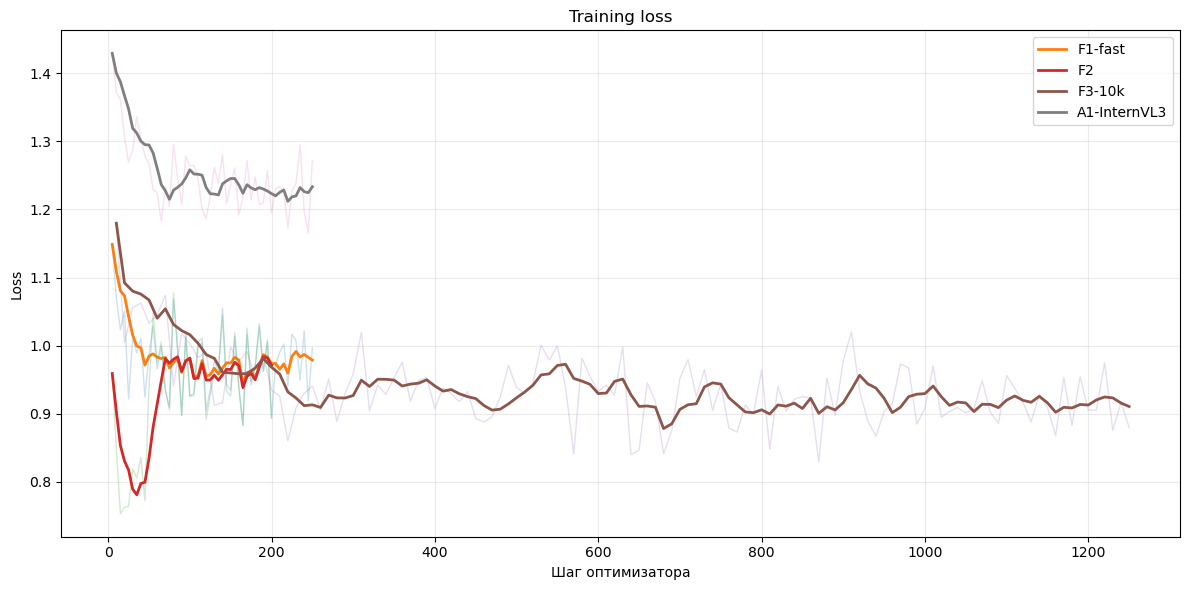

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
for model_name, frame in logs.groupby('model', sort=False):
    frame = frame.sort_values('step')
    ax.plot(frame.step, frame.loss, alpha=0.22, linewidth=1)
    ax.plot(frame.step, frame.loss.rolling(5, min_periods=1).mean(), linewidth=2, label=model_name)
ax.set(title='Training loss', xlabel='Шаг оптимизатора', ylabel='Loss')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_training_loss.png', dpi=180, bbox_inches='tight')
plt.show()

## 3. Learning rate

Во всех запусках используется разогрев и плавное уменьшение learning rate почти до нуля к завершению эпохи. Для F3 начальный learning rate снижен до `1e-4`, поскольку увеличен объём обучения.

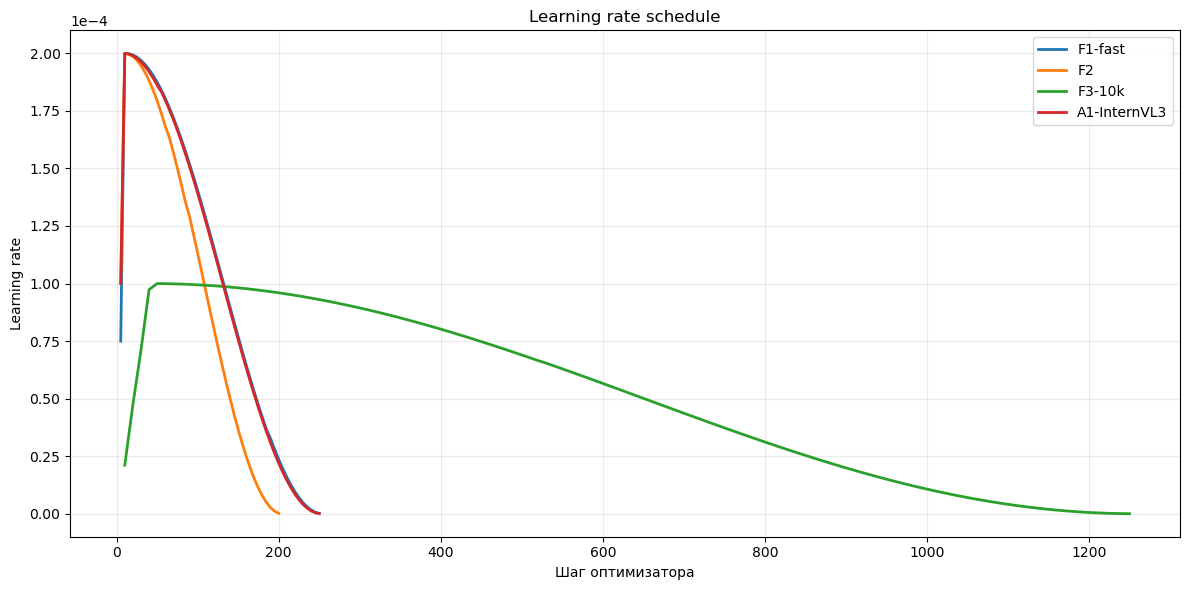

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
for model_name, frame in logs.groupby('model', sort=False):
    frame = frame.sort_values('step')
    ax.plot(frame.step, frame.learning_rate, linewidth=2, label=model_name)
ax.set(title='Learning rate schedule', xlabel='Шаг оптимизатора', ylabel='Learning rate')
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_learning_rate.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Норма градиента

Логарифмическая шкала позволяет одновременно видеть обычные значения и редкие всплески. Единичные пики не сопровождались NaN или остановкой обучения, а все итоговые адаптеры были успешно сохранены.

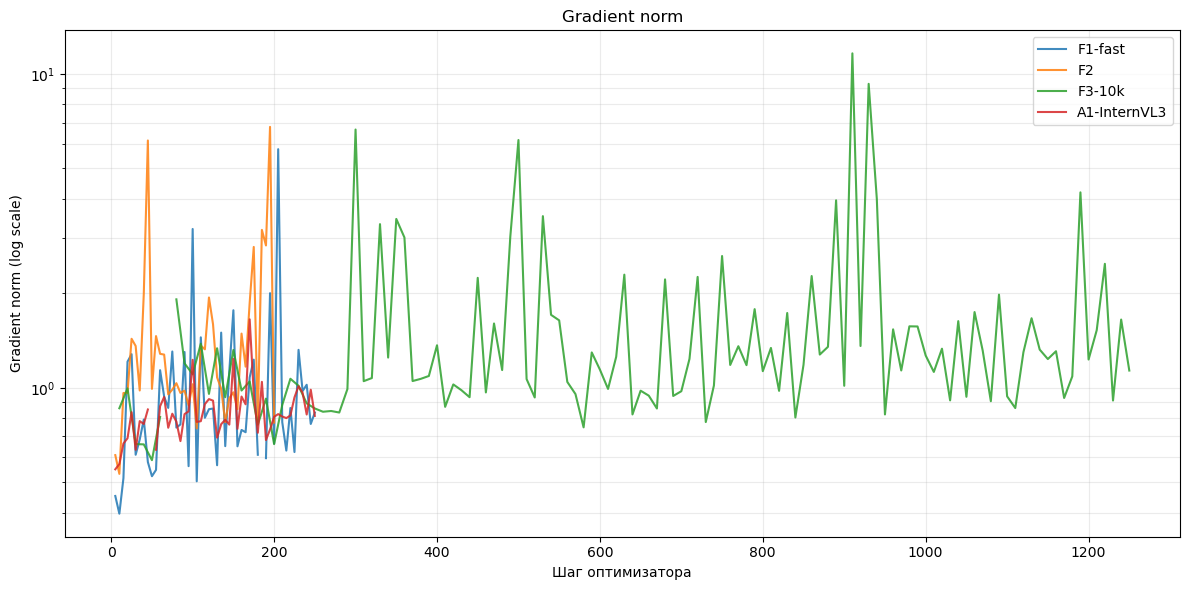

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
for model_name, frame in logs.groupby('model', sort=False):
    frame = frame.sort_values('step')
    ax.plot(frame.step, frame.grad_norm, linewidth=1.5, alpha=0.85, label=model_name)
ax.set(title='Gradient norm', xlabel='Шаг оптимизатора', ylabel='Gradient norm (log scale)', yscale='log')
ax.grid(alpha=0.25, which='both')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_gradient_norm.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Итоговая таблица запусков

Для сглаживания локальных колебаний в таблице используется средний loss по последним пяти записям. У F2 последний автоматически сохранённый checkpoint содержит историю до 200-го шага; итоговый адаптер был сохранён после завершения запуска на 250 плановых шагах.

In [6]:
summary_rows = []
for model_name, spec in RUNS.items():
    if model_name not in state_info:
        continue
    config = json.loads(spec['config'].read_text(encoding='utf-8'))
    history = state_info[model_name]['history'].sort_values('step')
    adapter_bytes = sum(path.stat().st_size for path in spec['adapter'].rglob('*') if path.is_file())
    planned_steps = config.get('total_steps', config['examples'] // 8)
    summary_rows.append({
        'model': model_name,
        'base_model': config['base_model'],
        'examples': config['examples'],
        'lora_rank': config['lora_rank'],
        'learning_rate': config['learning_rate'],
        'planned_steps': planned_steps,
        'last_logged_step': int(history.step.max()),
        'first_5_loss': history.loss.head(5).mean(),
        'last_5_loss': history.loss.tail(5).mean(),
        'minimum_logged_loss': history.loss.min(),
        'gradient_norm_p95': history.grad_norm.quantile(0.95),
        'adapter_size_mb': adapter_bytes / 1024 ** 2,
    })
summary = pd.DataFrame(summary_rows).round({
    'first_5_loss': 3, 'last_5_loss': 3, 'minimum_logged_loss': 3,
    'gradient_norm_p95': 3, 'adapter_size_mb': 1,
})
summary.to_csv(RESULTS_DIR / 'training_run_summary.csv', index=False)
display(summary)

,model,base_model,examples,lora_rank,learning_rate,planned_steps,last_logged_step,first_5_loss,last_5_loss,minimum_logged_loss,gradient_norm_p95,adapter_size_mb
0,F1-fast,Qwen/Qwen2.5-VL-3B-Instruct,2000,8,0.0002,250,250,1.043,0.979,0.882,1.908,81.9
1,F2,Qwen/Qwen2.5-VL-3B-Instruct,2000,16,0.0002,250,200,0.817,0.971,0.753,3.332,152.7
2,F3-10k,Qwen/Qwen2.5-VL-3B-Instruct,10000,16,0.0001,1250,1250,1.067,0.911,0.829,3.892,152.7
3,A1-InternVL3,OpenGVLab/InternVL3-2B-hf,2000,8,0.0002,250,250,1.348,1.233,1.165,1.155,50.7


## Выводы

- Все четыре запуска имеют сохранённую историю обучения и итоговый LoRA-адаптер.
- F1 и A1 завершили 250 шагов; F3 завершила 1 250 шагов. Для F2 история последнего checkpoint доступна до шага 200 из 250.
- У F3 скользящий loss в конце ниже начального уровня; обучение завершилось без расходимости и дало лучший результат на LLaVA holdout.
- У F2 loss колебался сильнее, поэтому преимущество rank 16 корректнее оценивать по независимым метрикам, а не по единственной последней точке loss.
- Размер итоговых адаптеров значительно меньше полной базовой модели: около 51–153 МБ. Это подтверждает практичность QLoRA для учебного проекта на одном GPU.